In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar los datos desde la carpeta 'data'
transactions = pd.read_csv("data/transactions.csv", parse_dates=["transaction_date"])
customers = pd.read_csv("data/customers.csv", parse_dates=["signup_date", "last_active_date"])

print(f"{len(customers):,} clientes · {len(transactions):,} transacciones")
print(f"Rango de fechas: {transactions['transaction_date'].min().date()} a {transactions['transaction_date'].max().date()}")
display(transactions.head())

2,000 clientes · 164,239 transacciones
Rango de fechas: 2024-09-02 a 2026-08-30


,transaction_id,customer_id,transaction_date,amount
0,1,1,2025-02-11,16.00
1,16,2,2025-10-15,9.13
2,5,2,2025-10-29,9.08
3,12,2,2025-11-06,9.48
4,15,2,2025-11-07,2.80


### Subir archivos interactivamente
Ejecuta la siguiente celda para crear la carpeta `data` y subir los archivos directamente desde tu computadora.

In [4]:
import os
from google.colab import files

# Crear la carpeta 'data' si no existe
os.makedirs('data', exist_ok=True)

print("Selecciona y sube 'transactions.csv' y 'customers.csv':")
uploaded = files.upload()

# Mover los archivos subidos a la carpeta 'data'
for filename in uploaded.keys():
    os.rename(filename, os.path.join('data', filename))
print("¡Archivos subidos y movidos a la carpeta 'data' con éxito!")

Selecciona y sube 'transactions.csv' y 'customers.csv':


Saving uplift_experiment.csv to uplift_experiment.csv
Saving transactions.csv to transactions.csv
Saving customers.csv to customers.csv
¡Archivos subidos y movidos a la carpeta 'data' con éxito!


In [8]:
transactions["month"] = transactions["transaction_date"].dt.to_period("M")

active_by_month = transactions.groupby("month")["customer_id"].apply(set).sort_index()
months = active_by_month.index.tolist()

retention_rows = []
for i in range(len(months) - 1):
    this_month, next_month = months[i], months[i + 1]
    active_this = active_by_month[this_month]
    active_next = active_by_month[next_month]
    retained = active_this & active_next
    retention_rows.append({
        "month": this_month,
        "active_customers": len(active_this),
        "retained_next_month": len(retained),
        "retention_rate": len(retained) / len(active_this),
    })

retention_df = pd.DataFrame(retention_rows).set_index("month")
retention_df.tail(12)

,active_customers,retained_next_month,retention_rate
month,,,
2025-08,659,597,0.905918
2025-09,691,631,0.913169
2025-10,741,656,0.885290
2025-11,738,677,0.917344
2025-12,773,707,0.914618
2026-01,811,731,0.901356
2026-02,819,746,0.910867
2026-03,849,759,0.893993
2026-04,862,791,0.917633


In [9]:
# TODO: usen los últimos 12 meses de la tabla de arriba para calcular una retención mensual promedio.
r_actual = retention_df["retention_rate"].tail(12).mean()
print(f"Retención mensual promedio (últimos 12 meses): {r_actual:.1%}")

Retención mensual promedio (últimos 12 meses): 90.6%


In [10]:
monthly = transactions.groupby("month").agg(
    revenue=("amount", "sum"),
    active_customers=("customer_id", "nunique"),
)
monthly["arpu"] = monthly["revenue"] / monthly["active_customers"]

arpu_actual = monthly["arpu"].tail(12).mean()
print(f"ARPU mensual promedio (últimos 12 meses): ${arpu_actual:.2f}")
monthly.tail(6)

ARPU mensual promedio (últimos 12 meses): $93.70


,revenue,active_customers,arpu
month,,,
2026-03,81948.01,849,96.522980
2026-04,81135.16,862,94.124316
2026-05,85793.56,876,97.937854
2026-06,84826.87,903,93.938948
2026-07,88691.31,907,97.785347
2026-08,84465.90,852,99.138380


In [11]:
# TODO: el CAC promedio ya está en customers.csv (columna acquisition_cost).
cac_actual = customers["acquisition_cost"].mean()
print(f"CAC promedio: ${cac_actual:.2f}")

CAC promedio: $13.59


In [12]:
MARGIN = 0.70
D_MONTHLY = 0.01

def clv(arpu, r, margin=MARGIN, d=D_MONTHLY, cac=cac_actual):
    multiplier = r / (1 + d - r)
    return (arpu * margin) * multiplier - cac, multiplier

clv_base, mult_base = clv(arpu_actual, r_actual)
print(f"r = {r_actual:.1%}  →  multiplicador = {mult_base:.2f}×  →  CLV = ${clv_base:,.2f}")

r = 90.6%  →  multiplicador = 8.76×  →  CLV = $560.81


In [13]:
retention_grid = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97]

table_rows = []
prev_mult = None
for r in retention_grid:
    clv_r, mult_r = clv(arpu_actual, r)
    change = None if prev_mult is None else (mult_r / prev_mult - 1)
    table_rows.append({
        "retencion_mensual": f"{r:.0%}",
        "multiplicador": round(mult_r, 2),
        "cambio_vs_anterior": None if change is None else f"{change:+.0%}",
        "CLV": round(clv_r, 2),
    })
    prev_mult = mult_r

multiplier_table = pd.DataFrame(table_rows)
multiplier_table

,retencion_mensual,multiplicador,cambio_vs_anterior,CLV
0,70%,2.26,None,134.51
1,80%,3.81,+69%,236.27
2,85%,5.31,+39%,334.85
3,90%,8.18,+54%,523.04
4,95%,15.83,+94%,1024.90
5,97%,24.25,+53%,1576.94


In [14]:
R_BASE = 0.90
R_TARGET = 0.95
AOV_LIFT = 0.10

clv_start, _ = clv(arpu_actual, R_BASE)

# Escenario A: sube el ARPU 10%, la retención se queda en 90%
clv_aov_up, _ = clv(arpu_actual * (1 + AOV_LIFT), R_BASE)
lift_aov = clv_aov_up / clv_start - 1

# Escenario B: sube la retención de 90% a 95%, el ARPU no cambia
clv_r_up, _ = clv(arpu_actual, R_TARGET)
lift_r = clv_r_up / clv_start - 1

print(f"CLV de partida (r=90%):               ${clv_start:,.2f}")
print(f"Escenario A — AOV +10%:                ${clv_aov_up:,.2f}   ({lift_aov:+.0%})")
print(f"Escenario B — retención 90% → 95%:      ${clv_r_up:,.2f}   ({lift_r:+.0%})")
print()
ganador = "la retención (Escenario B)" if lift_r > lift_aov else "el AOV (Escenario A)"
print(f"Gana: {ganador}")

CLV de partida (r=90%):               $523.04
Escenario A — AOV +10%:                $576.71   (+10%)
Escenario B — retención 90% → 95%:      $1,024.90   (+96%)

Gana: la retención (Escenario B)


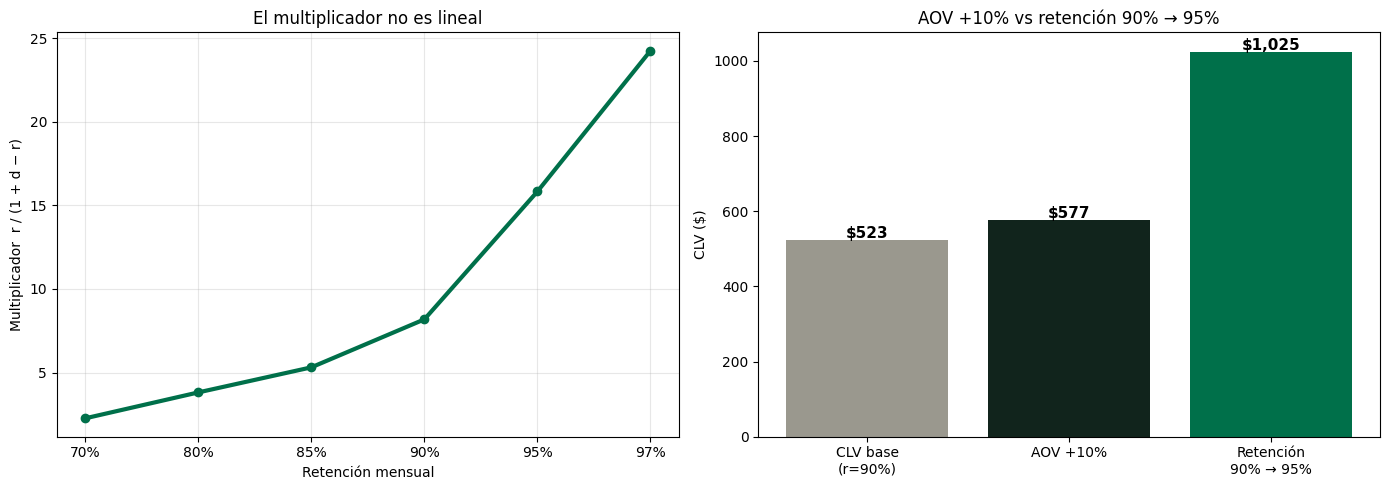

In [16]:
# Crear la figura y los subplots (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: curva del multiplicador
axes[0].plot(multiplier_table["retencion_mensual"], multiplier_table["multiplicador"],
             marker="o", linewidth=3, color="#00704A")
axes[0].set_title("El multiplicador no es lineal")
axes[0].set_xlabel("Retención mensual")
axes[0].set_ylabel("Multiplicador  r / (1 + d − r)")
axes[0].grid(alpha=0.3)

# Derecha: comparación de los dos escenarios
scenarios = ["CLV base\n(r=90%)", "AOV +10%", "Retención\n90% → 95%"]
values = [clv_start, clv_aov_up, clv_r_up]
colors = ["#9A988E", "#11241C", "#00704A"]
bars = axes[1].bar(scenarios, values, color=colors)
axes[1].set_title("AOV +10% vs retención 90% → 95%")
axes[1].set_ylabel("CLV ($)")
for bar, v in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 5, f"${v:,.0f}",
                 ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("clv_palanca_r_vs_aov.png", dpi=150)
plt.show()